In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import PowerTransformer

np.random.seed(42)

# 1. Strictly positive right-skewed data (e.g., Income/Prices)
positive_data = np.random.exponential(scale=3.0, size=500) + 0.5

# 2. Skewed data containing zero and negative values (e.g., Net Profit/Loss)
mixed_data = np.random.exponential(scale=3.0, size=500) - 2.0

df = pd.DataFrame({
    'Strictly_Positive': positive_data,
    'Mixed_Values': mixed_data
})

print(df.head())

   Strictly_Positive  Mixed_Values
0           1.907804      1.593592
1           9.530364      0.304235
2           4.450237     -0.888862
3           3.238828      3.042722
4           1.008875      1.462989


In [2]:
# Initialize PowerTransformer with method='box-cox'
pt_boxcox = PowerTransformer(method='box-cox', standardize=True)

# Fit and transform the strictly positive feature
# (Passing [[ ]] keeps it as a 2D array required by scikit-learn)
df['BoxCox_Transformed'] = pt_boxcox.fit_transform(df[['Strictly_Positive']])

# Check the optimal lambda found automatically by Box-Cox
print("Optimal Lambda for Box-Cox:", pt_boxcox.lambdas_[0])

Optimal Lambda for Box-Cox: 0.022573823835409568


**Code Breakdown:method='box-cox': Specifies the mathematical formula to use.standardize=True: Automatically scales the output data to have a mean of 0 and a variance of 1 (standard normal distribution).pt_boxcox.lambdas_: Stores the exact calculated $\lambda$ value used to normalize the column.**

In [3]:
# Initialize PowerTransformer with method='yeo-johnson' (default method)
pt_yeojohnson = PowerTransformer(method='yeo-johnson', standardize=True)

# Fit and transform the mixed-value feature (contains negative numbers)
df['YeoJohnson_Transformed'] = pt_yeojohnson.fit_transform(df[['Mixed_Values']])

# Check the optimal lambda found automatically by Yeo-Johnson
print("Optimal Lambda for Yeo-Johnson:", pt_yeojohnson.lambdas_[0])

Optimal Lambda for Yeo-Johnson: 0.2927880198517387


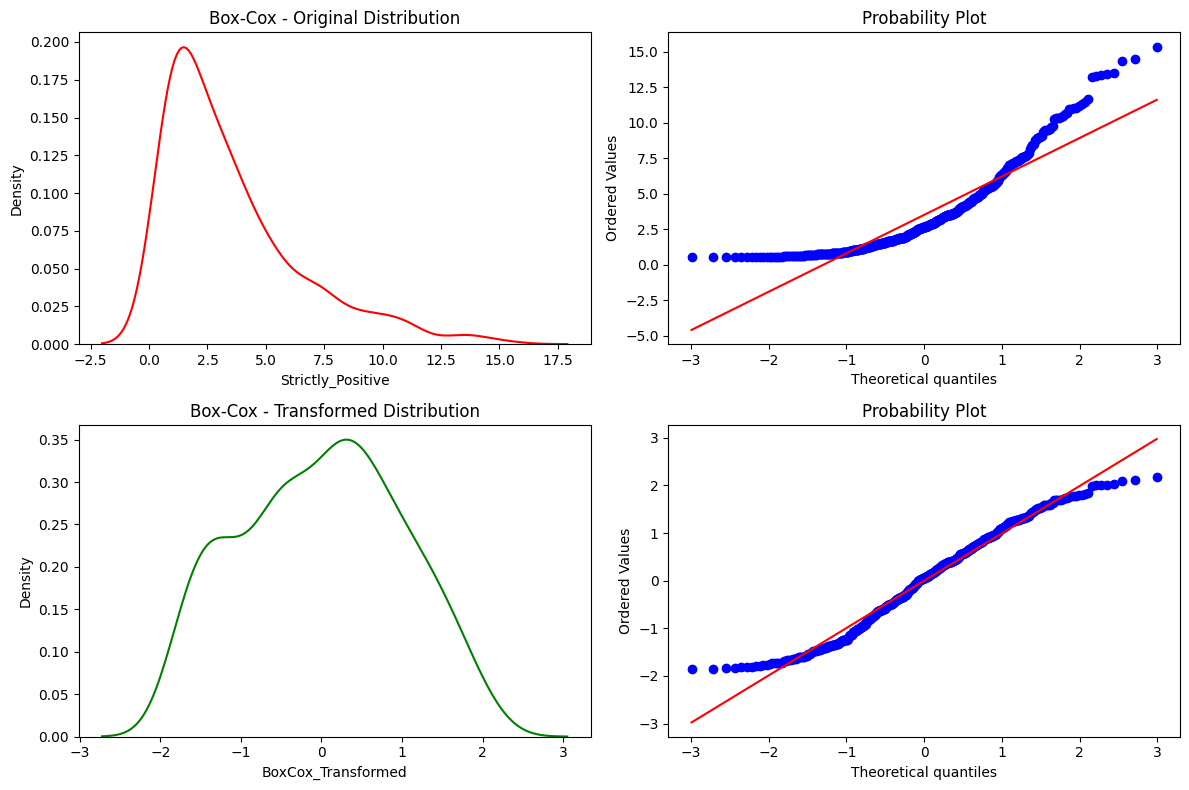

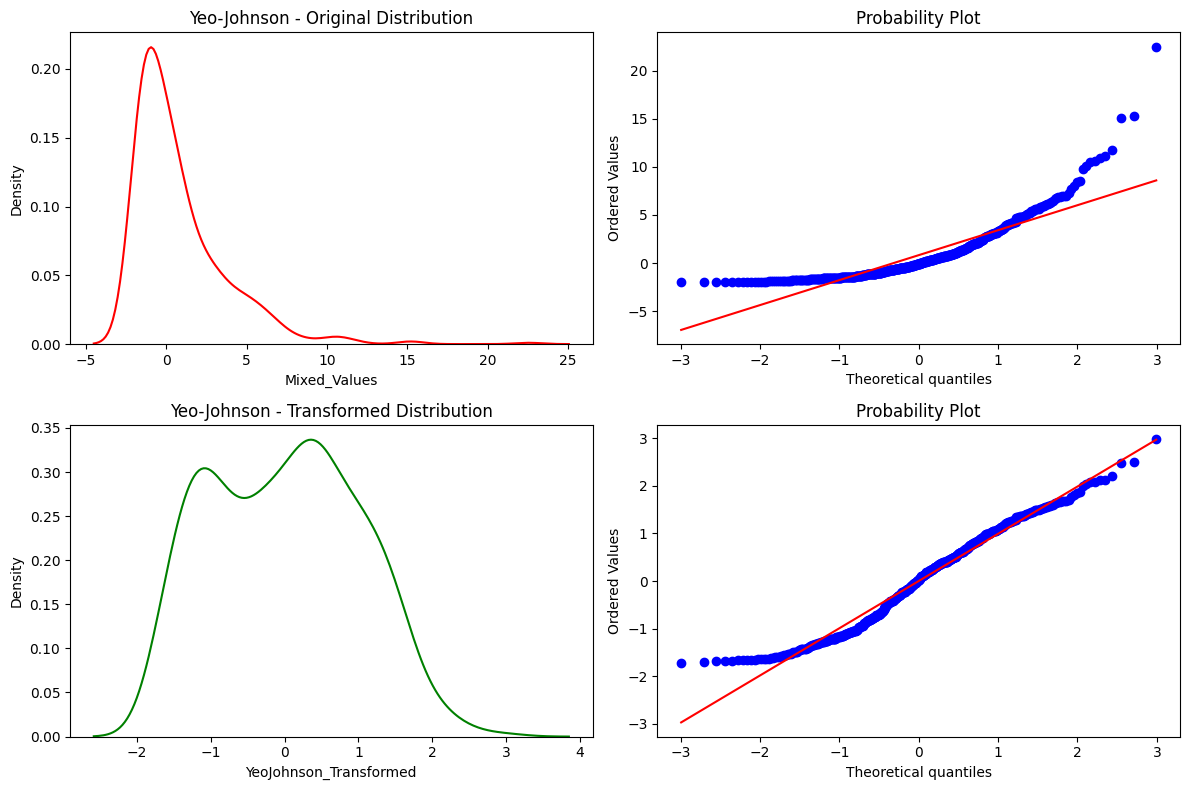

In [4]:
def plot_power_transformation(original_col, transformed_col, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # 1. Original Density Plot (KDE)
    axes[0, 0].set_title(f'{title} - Original Distribution')
    sns.kdeplot(original_col, ax=axes[0, 0], color='red')
    
    # 2. Original Q-Q Plot
    axes[0, 1].set_title(f'{title} - Original Q-Q Plot')
    stats.probplot(original_col, dist='norm', plot=axes[0, 1])
    
    # 3. Transformed Density Plot (KDE)
    axes[1, 0].set_title(f'{title} - Transformed Distribution')
    sns.kdeplot(transformed_col, ax=axes[1, 0], color='green')
    
    # 4. Transformed Q-Q Plot
    axes[1, 1].set_title(f'{title} - Transformed Q-Q Plot')
    stats.probplot(transformed_col, dist='norm', plot=axes[1, 1])
    
    plt.tight_layout()
    plt.show()

# Visualize Box-Cox results
plot_power_transformation(df['Strictly_Positive'], df['BoxCox_Transformed'], "Box-Cox")

# Visualize Yeo-Johnson results
plot_power_transformation(df['Mixed_Values'], df['YeoJohnson_Transformed'], "Yeo-Johnson")